# COS40007 Artificial Intelligence Engineering
## Portfolio Assessment 1 — Exploratory Data Analysis (EDA) & Data Preparation
### Dataset: Electrical Grid Stability Simulated Data (UCI Machine Learning Repository)

| | |
|---|---|
| **Student** | Hoang Huu Hoan |
| **Student ID** | 105732188 |
| **Task** | Portfolio Assessment 1 (EDA & Data Preparation) |
| **Submission date** | 4 October 2026 |

### Generative AI Use Declaration
I use GenAI to assist with structuring the analysis code, suggesting data-quality checks, debugging, improving code readability, and comments and plot labelling. All final code, interpretations, and conclusions are my own work after verification.

## Overview and how to run

**Engineering question.** Can the controller and power parameters of a simulated four-node *Decentral Smart Grid Control* (DSGC) system distinguish **stable** from **unstable** operating cases, and what does the data say about *why* a grid becomes unstable?

**Why this dataset is relevant to engineering.** Modern grids with high renewable penetration increasingly rely on *demand response*: consumers and producers adjust their power in reaction to a price signal. In the DSGC concept the price is tied to grid frequency, so every participant becomes part of a frequency-control feedback loop. Whether that loop is stable is a core electrical/control-engineering question that grid operators must answer before rolling such schemes out.

**Reproducibility.** Run *Kernel → Restart & Run All* from the folder containing this notebook. The CSV is read from `data/Data_for_UCI_named.csv`; figures are written to `figures/` and tables to `tables/`. Dependencies: Python ≥ 3.10, pandas, numpy, matplotlib, Jupyter (no other packages). The data is licensed CC BY 4.0 (Arzamasov, 2018).

## 0. Setup

All imports, paths and plotting defaults are defined once here so every later cell is reproducible. A fixed random seed is used for the only random step (the pairplot sub-sample).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

# --- Paths -------------------------------------------------------------------------
DATA_PATH = Path('data/Data_for_UCI_named.csv')
FIGURE_DIR = Path('figures')
TABLE_DIR = Path('tables')
FIGURE_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

# --- Reproducibility ---------------------------------------------------------------
RANDOM_SEED = 7
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}')

# --- Consistent plot style ---------------------------------------------------------
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 180, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e6e6', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
})
CLASS_COLORS = {'stable': '#2a78d6', 'unstable': '#eb6834'}   # colour-blind-safe pair (validated)
GROUP_COLORS = {'tau': '#2a78d6', 'g': '#eb6834', 'p': '#1baf7a'}

# --- Units from the UCI data dictionary (p is power normalised by inertia, hence s^-2) ---
UNITS = {**{f'tau{i}': 's' for i in range(1, 5)},
         **{f'p{i}': 's$^{-2}$' for i in range(1, 5)},
         **{f'g{i}': 's$^{-1}$' for i in range(1, 5)},
         'stab': 's$^{-1}$'}
def label_with_unit(col):
    return f'{col} ({UNITS[col]})' if col in UNITS else col

Python 3.13.16 | pandas 3.0.5 | numpy 2.5.3 | matplotlib 3.11.2


## 1. Dataset loading and initial exploration (Task 1)

Each row is one simulated operating configuration of a four-node **star** grid: one producer at the centre (node 1) feeding three consumers (nodes 2–4). It is **not** a time-stamped field measurement. The raw file is kept unchanged in `df_raw`; all checks use a separate working copy `df`.

The data dictionary below is taken from the UCI repository page (Arzamasov, 2018).

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy(deep=True)          # working copy; df_raw is never modified

# Data dictionary (from the UCI repository description)
data_dictionary = pd.DataFrame([
    ('tau1–tau4', 'Reaction time of each participant to the price signal (tau1 = producer)', 's, [0.5, 10]', 'Predictor'),
    ('p1',        'Nominal power produced by node 1; p1 = |p2 + p3 + p4|',                  's^-2',          'Derived - excluded'),
    ('p2–p4',     'Nominal power consumed by each consumer (negative = consumption)',         's^-2, [-2, -0.5]', 'Predictor'),
    ('g1–g4',     'Coefficient gamma proportional to price elasticity (acts as controller gain)', 's^-1, [0.05, 1]', 'Predictor'),
    ('stab',      'Maximal real part of the characteristic-equation root (> 0 = unstable)',   's^-1',          'Leaks target - excluded'),
    ('stabf',     'Stability label: stable / unstable',                                      'categorical',   'TARGET'),
], columns=['column(s)', 'meaning', 'unit / range', 'role'])
display(data_dictionary)

print('Dataset shape (rows, columns):', df.shape)
print('\nFirst five rows:')
display(df.head())
print('Data types of all columns:')
display(df.dtypes.rename('dtype').to_frame().T)
print('Basic statistical summary (numerical columns):')
display(df.describe().T.round(4))
print('Initial missing-value check (count per column):')
display(df.isna().sum().rename('missing_count').to_frame().T)

,column(s),meaning,unit / range,role
0,tau1–tau4,Reaction time of each participant to the price...,"s, [0.5, 10]",Predictor
1,p1,Nominal power produced by node 1; p1 = |p2 + p...,s^-2,Derived - excluded
2,p2–p4,Nominal power consumed by each consumer (negat...,"s^-2, [-2, -0.5]",Predictor
3,g1–g4,Coefficient gamma proportional to price elasti...,"s^-1, [0.05, 1]",Predictor
4,stab,Maximal real part of the characteristic-equati...,s^-1,Leaks target - excluded
5,stabf,Stability label: stable / unstable,categorical,TARGET


Dataset shape (rows, columns): (10000, 14)

First five rows:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


Data types of all columns:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str


Basic statistical summary (numerical columns):


,count,mean,std,min,25%,50%,75%,max
tau1,10000.0,5.2500,2.7425,0.5008,2.8749,5.2500,7.6247,9.9995
tau2,10000.0,5.2500,2.7425,0.5001,2.8751,5.2500,7.6249,9.9998
tau3,10000.0,5.2500,2.7425,0.5008,2.8755,5.2500,7.6249,9.9995
tau4,10000.0,5.2500,2.7426,0.5005,2.8750,5.2497,7.6248,9.9994
p1,10000.0,3.7500,0.7522,1.5826,3.2183,3.7510,4.2824,5.8644
p2,10000.0,-1.2500,0.4330,-1.9999,-1.6249,-1.2500,-0.8750,-0.5001
p3,10000.0,-1.2500,0.4330,-1.9999,-1.6250,-1.2500,-0.8750,-0.5001
p4,10000.0,-1.2500,0.4330,-1.9999,-1.6250,-1.2500,-0.8751,-0.5000
g1,10000.0,0.5250,0.2743,0.0500,0.2875,0.5250,0.7624,0.9999
g2,10000.0,0.5250,0.2743,0.0501,0.2876,0.5250,0.7625,0.9999


Initial missing-value check (count per column):


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0


**Observations (Task 1)**

- The file has **10,000 rows × 14 columns**, matching the UCI description; 13 columns are `float64` and the target `stabf` is text (pandas 3 shows this as `str`; older pandas shows `object`).
- The initial check finds **no missing values** in any column.
- Every input sits inside the documented simulation range (e.g. `tau` 0.50–10.00 s, `g` 0.05–1.00 s⁻¹, consumer `p` −2.00 to −0.50 s⁻²) and every input has a mean almost exactly at the centre of its range (`tau` mean 5.25, `g` mean 0.525, `p2–p4` mean −1.25). This already suggests the inputs were **sampled evenly across a design range** rather than observed from a real grid — an important point for interpretation later.
- `p1` is always positive (the producer) and `stab` takes both signs; its sign defines the label.

## 2. Data quality assessment (Task 2)

Checks performed: (a) missing values with percentages and a heatmap, (b) exact duplicates, (c) outliers with the 1.5 × IQR rule plus boxplots for **all** numerical columns, (d) physical/documented range and consistency checks, and (e) data types before vs after cleaning.

The IQR rule is used only to **flag** values for investigation; a flagged value is removed only if there is evidence that it is physically impossible or an error.

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
missing_count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
missing_percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


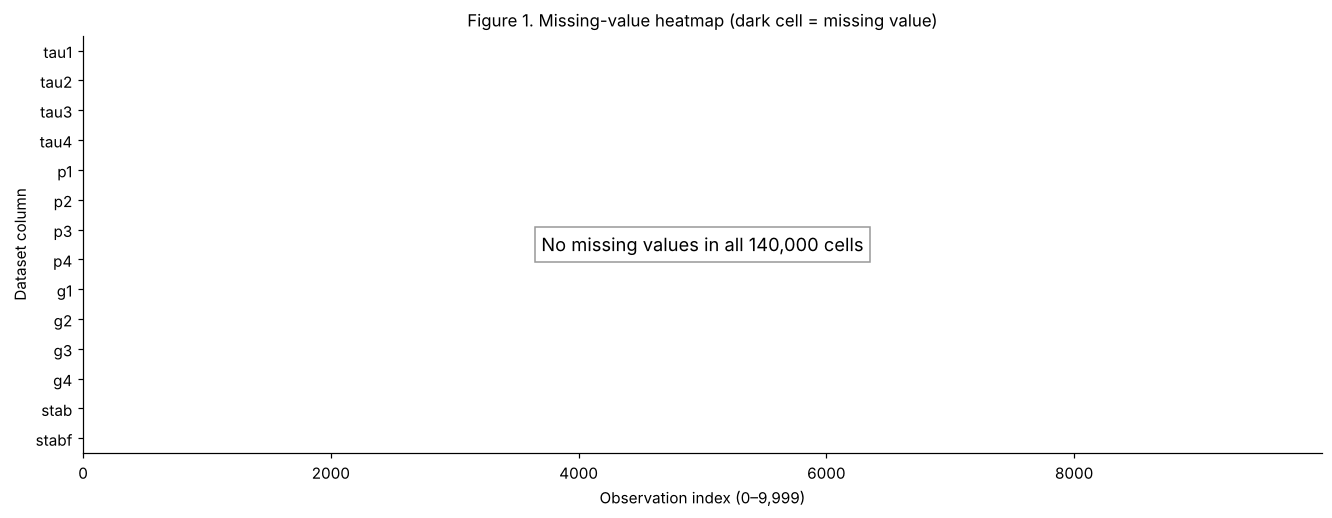

In [3]:
# (a) Missing values: count and percentage for every column
missing = pd.DataFrame({'missing_count': df.isna().sum(),
                        'missing_percent': (df.isna().mean() * 100).round(3)})
display(missing.T)
missing.to_csv(TABLE_DIR / 'missingness.csv')

# Missing-value heatmap: rows = columns of the dataset, x = observation index
fig, ax = plt.subplots(figsize=(12, 4.6), constrained_layout=True)
ax.imshow(df.isna().to_numpy().T, aspect='auto', interpolation='nearest', cmap='Greys', vmin=0, vmax=1)
ax.set_yticks(range(df.shape[1]), df.columns)
ax.set_xlabel('Observation index (0–9,999)')
ax.set_ylabel('Dataset column')
ax.grid(False)
ax.set_title('Figure 1. Missing-value heatmap (dark cell = missing value)')
if not df.isna().to_numpy().any():
    ax.text(0.5, 0.5, f'No missing values in all {df.size:,} cells', transform=ax.transAxes,
            ha='center', va='center', fontsize=12, bbox={'facecolor': 'white', 'edgecolor': '#999999'})
fig.savefig(FIGURE_DIR / '01_missingness_heatmap.png')
plt.show()

In [4]:
# (b) Exact duplicate rows (all 14 columns identical) and duplicates on inputs only
duplicate_count = int(df.duplicated().sum())
input_duplicate_count = int(df.drop(columns=['stab', 'stabf']).duplicated().sum())
print(f'Exact duplicate rows: {duplicate_count} ({duplicate_count / len(df):.2%})')
print(f'Duplicate input configurations (ignoring stab/stabf): {input_duplicate_count}')
if duplicate_count:
    display(df.loc[df.duplicated(keep=False)].head(10))
else:
    print('No duplicate examples to display.')

Exact duplicate rows: 0 (0.00%)
Duplicate input configurations (ignoring stab/stabf): 0
No duplicate examples to display.


,lower_fence,upper_fence,minimum,maximum,iqr_flag_count,iqr_flag_percent
tau1,-4.2498,14.7494,0.5008,9.9995,0,0.00
tau2,-4.2495,14.7495,0.5001,9.9998,0,0.00
tau3,-4.2486,14.7491,0.5008,9.9995,0,0.00
tau4,-4.2499,14.7497,0.5005,9.9994,0,0.00
p1,1.6221,5.8786,1.5826,5.8644,1,0.01
p2,-2.7498,0.2499,-1.9999,-0.5001,0,0.00
p3,-2.7500,0.2499,-1.9999,-0.5001,0,0.00
p4,-2.7498,0.2498,-1.9999,-0.5000,0,0.00
g1,-0.4248,1.4748,0.0500,0.9999,0,0.00
g2,-0.4249,1.4749,0.0501,0.9999,0,0.00


Flagged row(s):


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
6273,6.698111,7.861157,9.33348,2.433936,1.58259,-0.503865,-0.571522,-0.507202,0.641753,0.868178,0.494277,0.410666,0.056923,unstable


,check_passed
"tau1–tau4 within [0.5, 10] s",True
"g1–g4 within [0.05, 1] s^-1",True
"p2–p4 within [-2, -0.5] s^-2",True
Power balance: p1 = |p2 + p3 + p4|,True
"stabf = ""unstable"" exactly when stab > 0",True


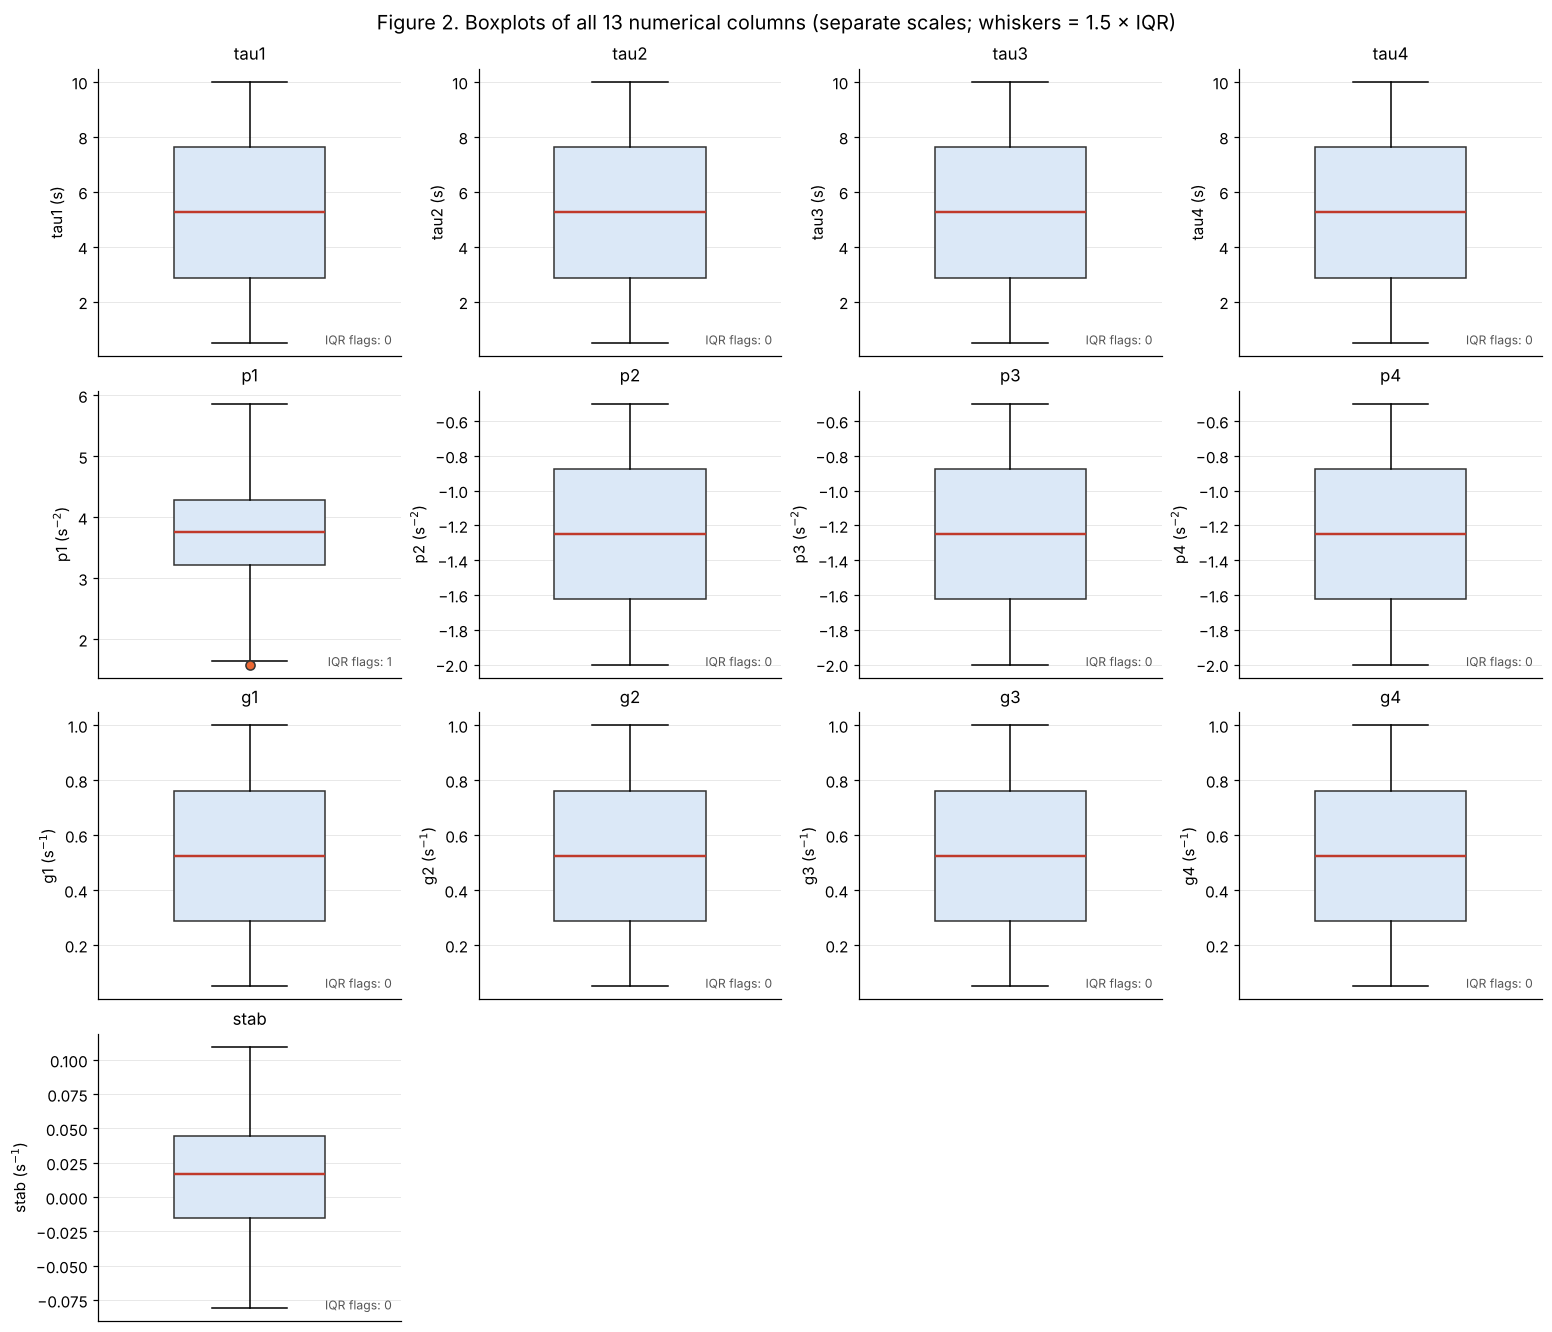

In [5]:
# (c) Outlier screen with the 1.5 x IQR rule (screening only)
numeric_cols = df.select_dtypes(include='number').columns.tolist()
q1, q3 = df[numeric_cols].quantile(0.25), df[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_mask = (df[numeric_cols] < lower) | (df[numeric_cols] > upper)
outlier_summary = pd.DataFrame({'lower_fence': lower, 'upper_fence': upper,
                                'minimum': df[numeric_cols].min(), 'maximum': df[numeric_cols].max(),
                                'iqr_flag_count': outlier_mask.sum(),
                                'iqr_flag_percent': (outlier_mask.mean() * 100).round(2)})
display(outlier_summary.round(4))
outlier_summary.to_csv(TABLE_DIR / 'outlier_screen.csv')
print('Flagged row(s):')
display(df.loc[outlier_mask.any(axis=1)])

# (d) Documented-range and physical-consistency checks
tau_cols = [f'tau{i}' for i in range(1, 5)]
g_cols = [f'g{i}' for i in range(1, 5)]
consumer_p = ['p2', 'p3', 'p4']
range_checks = pd.Series({
    'tau1–tau4 within [0.5, 10] s': bool(df[tau_cols].ge(0.5).all().all() and df[tau_cols].le(10).all().all()),
    'g1–g4 within [0.05, 1] s^-1': bool(df[g_cols].ge(0.05).all().all() and df[g_cols].le(1).all().all()),
    'p2–p4 within [-2, -0.5] s^-2': bool(df[consumer_p].ge(-2).all().all() and df[consumer_p].le(-0.5).all().all()),
    'Power balance: p1 = |p2 + p3 + p4|': bool(np.allclose(df.p1, (df.p2 + df.p3 + df.p4).abs(), atol=1e-10)),
    'stabf = "unstable" exactly when stab > 0': bool((df.stabf == np.where(df.stab > 0, 'unstable', 'stable')).all()),
}, name='check_passed')
display(range_checks.to_frame())

# Boxplots: one axis per numerical column so different scales do not hide extremes
fig, axes = plt.subplots(4, 4, figsize=(14, 12), constrained_layout=True)
for ax, col in zip(axes.flat, numeric_cols):
    ax.boxplot(df[col], showfliers=True, widths=0.5, patch_artist=True,
               boxprops={'facecolor': '#dbe8f7', 'edgecolor': '#333333'},
               medianprops={'color': '#c0392b', 'linewidth': 1.6},
               flierprops={'marker': 'o', 'markerfacecolor': '#eb6834', 'markeredgecolor': '#333333', 'markersize': 6})
    ax.set_title(col)
    ax.set_ylabel(label_with_unit(col))
    ax.set_xticks([])
    n_flag = int(outlier_mask[col].sum())
    ax.text(0.97, 0.03, f'IQR flags: {n_flag}', transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='#555555')
for ax in axes.flat[len(numeric_cols):]:
    ax.axis('off')
fig.suptitle('Figure 2. Boxplots of all 13 numerical columns (separate scales; whiskers = 1.5 × IQR)', fontsize=13)
fig.savefig(FIGURE_DIR / '02_all_numeric_boxplots.png')
plt.show()

In [6]:
# (e) Cleaning decision log and data types after cleaning
df_clean = df.copy()   # no rows/values changed: see the decisions in the markdown below
quality_before_after = pd.DataFrame([
    {'stage': 'raw input', 'rows': len(df_raw), 'columns': df_raw.shape[1],
     'missing_cells': int(df_raw.isna().sum().sum()), 'duplicate_rows': int(df_raw.duplicated().sum())},
    {'stage': 'after quality audit', 'rows': len(df_clean), 'columns': df_clean.shape[1],
     'missing_cells': int(df_clean.isna().sum().sum()), 'duplicate_rows': int(df_clean.duplicated().sum())},
])
display(quality_before_after)
quality_before_after.to_csv(TABLE_DIR / 'quality_before_after.csv', index=False)
display(df_clean.dtypes.rename('dtype_after_cleaning').to_frame().T)

,stage,rows,columns,missing_cells,duplicate_rows
0,raw input,10000,14,0,0
1,after quality audit,10000,14,0,0


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
dtype_after_cleaning,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str


**Observations and handling decisions (Task 2)**

| Issue | Evidence | Decision and justification |
|---|---|---|
| Missing values | 0 of 140,000 cells (0 % in every column, Figure 1) | No imputation needed; all 10,000 rows kept. |
| Duplicates | 0 exact duplicate rows and 0 duplicate input configurations | Nothing to remove; every row is a distinct scenario. |
| Outliers | 1.5 × IQR flags only **one** value, `p1` = 1.583 (0.01 %, Figure 2); all other columns have 0 flags | **Retained.** `p1` is the sum of three uniform consumer powers, so its distribution is bell-shaped and a low tail value is expected. The flagged row (index 6273) is simply the case where all three consumers draw close to their minimum 0.5 s⁻². 1.583 s⁻² is inside the physically possible range (1.5–6 s⁻²) and satisfies the power balance exactly, so it is a genuine scenario, not an error. `p1` is excluded from the predictors anyway. |
| Range / consistency | All `tau`, `g`, `p` values inside documented ranges; `p1 = abs(p2 + p3 + p4)` holds to floating-point precision; label agrees with the sign of `stab` in 100 % of rows | The data is internally consistent. These checks also prove `p1` is redundant and `stab` encodes the label (both excluded from predictors). |
| Data types | 13 × `float64`, `stabf` text — unchanged after cleaning | Types are appropriate; the target is mapped to 0/1 only where a numeric form is needed (Section 3). |

Overall the data quality is **very high**, as expected for simulation output. The main quality risk is not dirty data but **target leakage** (`stab`) and **redundancy** (`p1`), which are handled by excluding both from the predictor set.

## 3. Target variable preparation (Task 3)

The target is `stabf`, which is **already categorical** (`stable` / `unstable`), so this is a **binary classification** problem and the 3–5 class discretisation rule for numerical targets does not apply (brief 1.2). Following brief 1.2, the class balance is verified against the 80 % severe-imbalance threshold.

`stab` (the numerical stability margin) is shown as diagnostic context only: its sign *is* the label, so using it as a predictor would leak the answer. For correlation analysis the label is mapped as **stable = 0, unstable = 1**.

Target: stabf | dtype: str | problem type: binary classification


,count,percent
stabf,,
stable,3620,36.2
unstable,6380,63.8


Severe imbalance (any class > 80 %)? False
Imbalance ratio unstable:stable = 1.76 : 1

Summary statistics of the numerical stability margin stab, by class (diagnostic only):


,count,mean,std,min,25%,50%,75%,max
stabf,,,,,,,,
stable,3620.0,-0.0248,0.0148,-0.0808,-0.0359,-0.0237,-0.0126,-0.0000
unstable,6380.0,0.0387,0.0235,0.0000,0.0196,0.0366,0.0555,0.1094


Cases close to the stability boundary (|stab| < 0.01 s^-1): 14.8 %


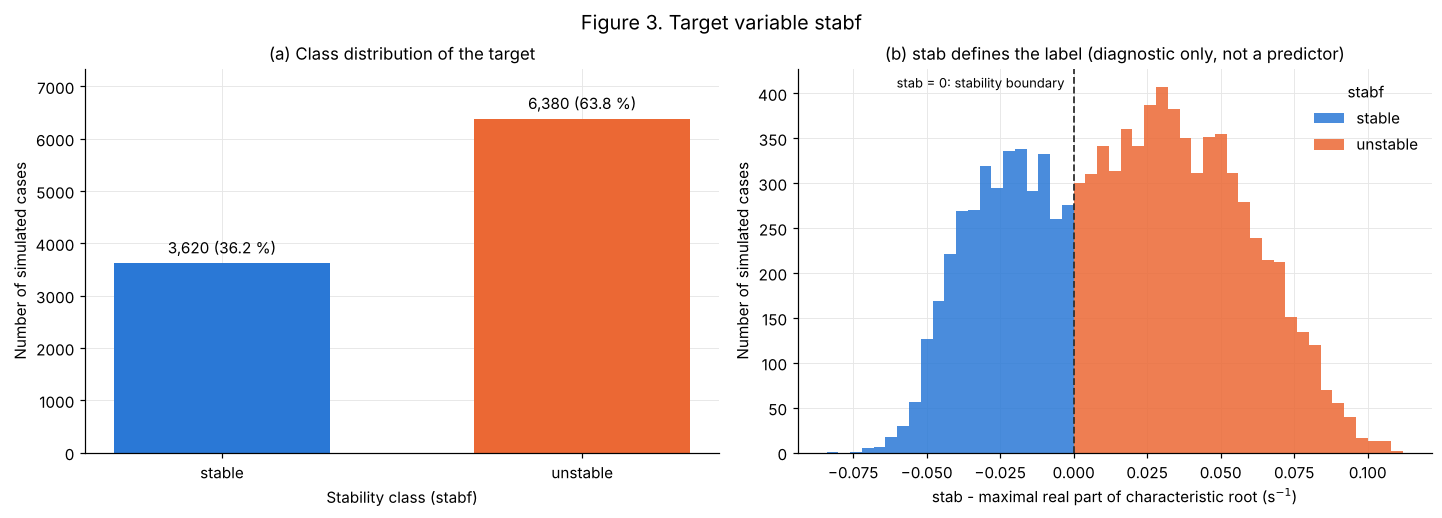

In [7]:
target = 'stabf'
label_order = ['stable', 'unstable']
class_map = {'stable': 0, 'unstable': 1}
y_binary = df[target].map(class_map)
assert df[target].notna().all() and set(df[target].unique()) == set(label_order)

print(f'Target: {target} | dtype: {df[target].dtype} | problem type: binary classification')
class_distribution = df[target].value_counts().reindex(label_order).rename('count').to_frame()
class_distribution['percent'] = (class_distribution['count'] / len(df) * 100).round(2)
display(class_distribution)
class_distribution.to_csv(TABLE_DIR / 'target_class_distribution.csv')
print('Severe imbalance (any class > 80 %)?', bool((class_distribution['percent'] > 80).any()))
print(f"Imbalance ratio unstable:stable = {class_distribution.loc['unstable','count'] / class_distribution.loc['stable','count']:.2f} : 1")

print('\nSummary statistics of the numerical stability margin stab, by class (diagnostic only):')
display(df.groupby(target)['stab'].describe().round(4))
near_boundary = (df['stab'].abs() < 0.01).mean() * 100
print(f'Cases close to the stability boundary (|stab| < 0.01 s^-1): {near_boundary:.1f} %')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)
ax = axes[0]
bars = ax.bar(class_distribution.index, class_distribution['count'],
              color=[CLASS_COLORS[c] for c in class_distribution.index], width=0.6)
for bar, (_, row) in zip(bars, class_distribution.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, row['count'] + 120, f"{int(row['count']):,} ({row['percent']:.1f} %)",
            ha='center', va='bottom')
ax.set_ylim(0, class_distribution['count'].max() * 1.15)
ax.set_xlabel('Stability class (stabf)')
ax.set_ylabel('Number of simulated cases')
ax.set_title('(a) Class distribution of the target')

ax = axes[1]
bins = np.arange(-0.084, 0.1121, 0.004)   # bin edges aligned so that 0 is an edge
bins[np.isclose(bins, 0)] = 0.0
for label in label_order:
    ax.hist(df.loc[df[target] == label, 'stab'], bins=bins, color=CLASS_COLORS[label], alpha=0.85, label=label)
ax.axvline(0, color='#333333', linestyle='--', linewidth=1.2)
ax.annotate('stab = 0: stability boundary', xy=(0, 1.0), xycoords=('data', 'axes fraction'), xytext=(-6, -4),
            textcoords='offset points', ha='right', va='top', fontsize=8.5)
ax.set_xlabel('stab - maximal real part of characteristic root (s$^{-1}$)')
ax.set_ylabel('Number of simulated cases')
ax.set_title('(b) stab defines the label (diagnostic only, not a predictor)')
ax.legend(title='stabf', frameon=False)
fig.suptitle('Figure 3. Target variable stabf', fontsize=13)
fig.savefig(FIGURE_DIR / '03_target_distribution.png')
plt.show()

**Observations (Task 3)**

- **Target:** `stabf` (text, two classes) → **binary classification**. No discretisation was performed because the target is already categorical.
- **Class balance:** 3,620 stable (36.2 %) vs 6,380 unstable (63.8 %), a ratio of about 1.76 : 1. This is a *moderate* imbalance; no class exceeds 80 %, so the brief's severe-imbalance condition is not met. A naive model that always predicts "unstable" would already score 63.8 % accuracy, so later modelling must report **balanced accuracy, per-class recall/F1 and a confusion matrix**, and use a **stratified** train/test split.
- **Figure 3b** confirms that the label is a hard threshold on `stab` (unstable ⇔ `stab` > 0). `stab` is roughly bell-shaped and centred slightly above zero, and about 15 % of cases lie within ±0.01 s⁻¹ of the boundary — these near-boundary cases will be the hardest to classify.

## 4. Univariate analysis (Task 4)

**Predictors analysed (11):** `tau1`, `tau2`, `tau3`, `tau4` (reaction times), `p2`, `p3`, `p4` (consumer powers) and `g1`, `g2`, `g3`, `g4` (price elasticities). `p1` is excluded because it is an exact function of `p2–p4`, and `stab`/`stabf` are the target.

For each predictor we report summary statistics, a histogram, and a test of the distribution shape. Because the histograms look flat, the shape is tested against a **uniform distribution** on the documented range: a uniform variable has skewness 0 and excess kurtosis −1.2, and the Kolmogorov–Smirnov distance *D* (largest gap between the empirical and the uniform cumulative distribution) should be small. For a purely random sample of n = 10,000 the 5 % critical value of *D* is ≈ 1.36/√n = 0.0136.

Predictors: tau1, tau2, tau3, tau4, p2, p3, p4, g1, g2, g3, g4


,count,mean,std,min,25%,50%,75%,max,skewness,excess_kurtosis
tau1,10000.0,5.250,2.7425,0.5008,2.8749,5.2500,7.6247,9.9995,-0.0,-1.2
tau2,10000.0,5.250,2.7425,0.5001,2.8751,5.2500,7.6249,9.9998,0.0,-1.2
tau3,10000.0,5.250,2.7425,0.5008,2.8755,5.2500,7.6249,9.9995,-0.0,-1.2
tau4,10000.0,5.250,2.7426,0.5005,2.8750,5.2497,7.6248,9.9994,-0.0,-1.2
p2,10000.0,-1.250,0.4330,-1.9999,-1.6249,-1.2500,-0.8750,-0.5001,0.0,-1.2
p3,10000.0,-1.250,0.4330,-1.9999,-1.6250,-1.2500,-0.8750,-0.5001,0.0,-1.2
p4,10000.0,-1.250,0.4330,-1.9999,-1.6250,-1.2500,-0.8751,-0.5000,0.0,-1.2
g1,10000.0,0.525,0.2743,0.0500,0.2875,0.5250,0.7624,0.9999,0.0,-1.2
g2,10000.0,0.525,0.2743,0.0501,0.2876,0.5250,0.7625,0.9999,-0.0,-1.2
g3,10000.0,0.525,0.2743,0.0501,0.2875,0.5250,0.7624,1.0000,0.0,-1.2


KS 5% critical value for n=10000: 0.0136


,skewness,excess_kurtosis,KS_D_vs_uniform,uniform_reference,one_value_per_stratum,distribution_type
tau1,-0.00001,-1.2000,0.000100,"skew 0, kurt -1.2",True,Uniform
tau2,0.00000,-1.2000,0.000100,"skew 0, kurt -1.2",True,Uniform
tau3,-0.00000,-1.2000,0.000100,"skew 0, kurt -1.2",True,Uniform
tau4,-0.00000,-1.2000,0.000100,"skew 0, kurt -1.2",True,Uniform
p2,0.00000,-1.2000,0.000100,"skew 0, kurt -1.2",True,Uniform
p3,0.00000,-1.2000,0.000100,"skew 0, kurt -1.2",True,Uniform
p4,0.00000,-1.2000,0.000100,"skew 0, kurt -1.2",True,Uniform
g1,0.00000,-1.2000,0.000100,"skew 0, kurt -1.2",True,Uniform
g2,-0.00000,-1.2000,0.000100,"skew 0, kurt -1.2",True,Uniform
g3,0.00000,-1.2000,0.000100,"skew 0, kurt -1.2",True,Uniform


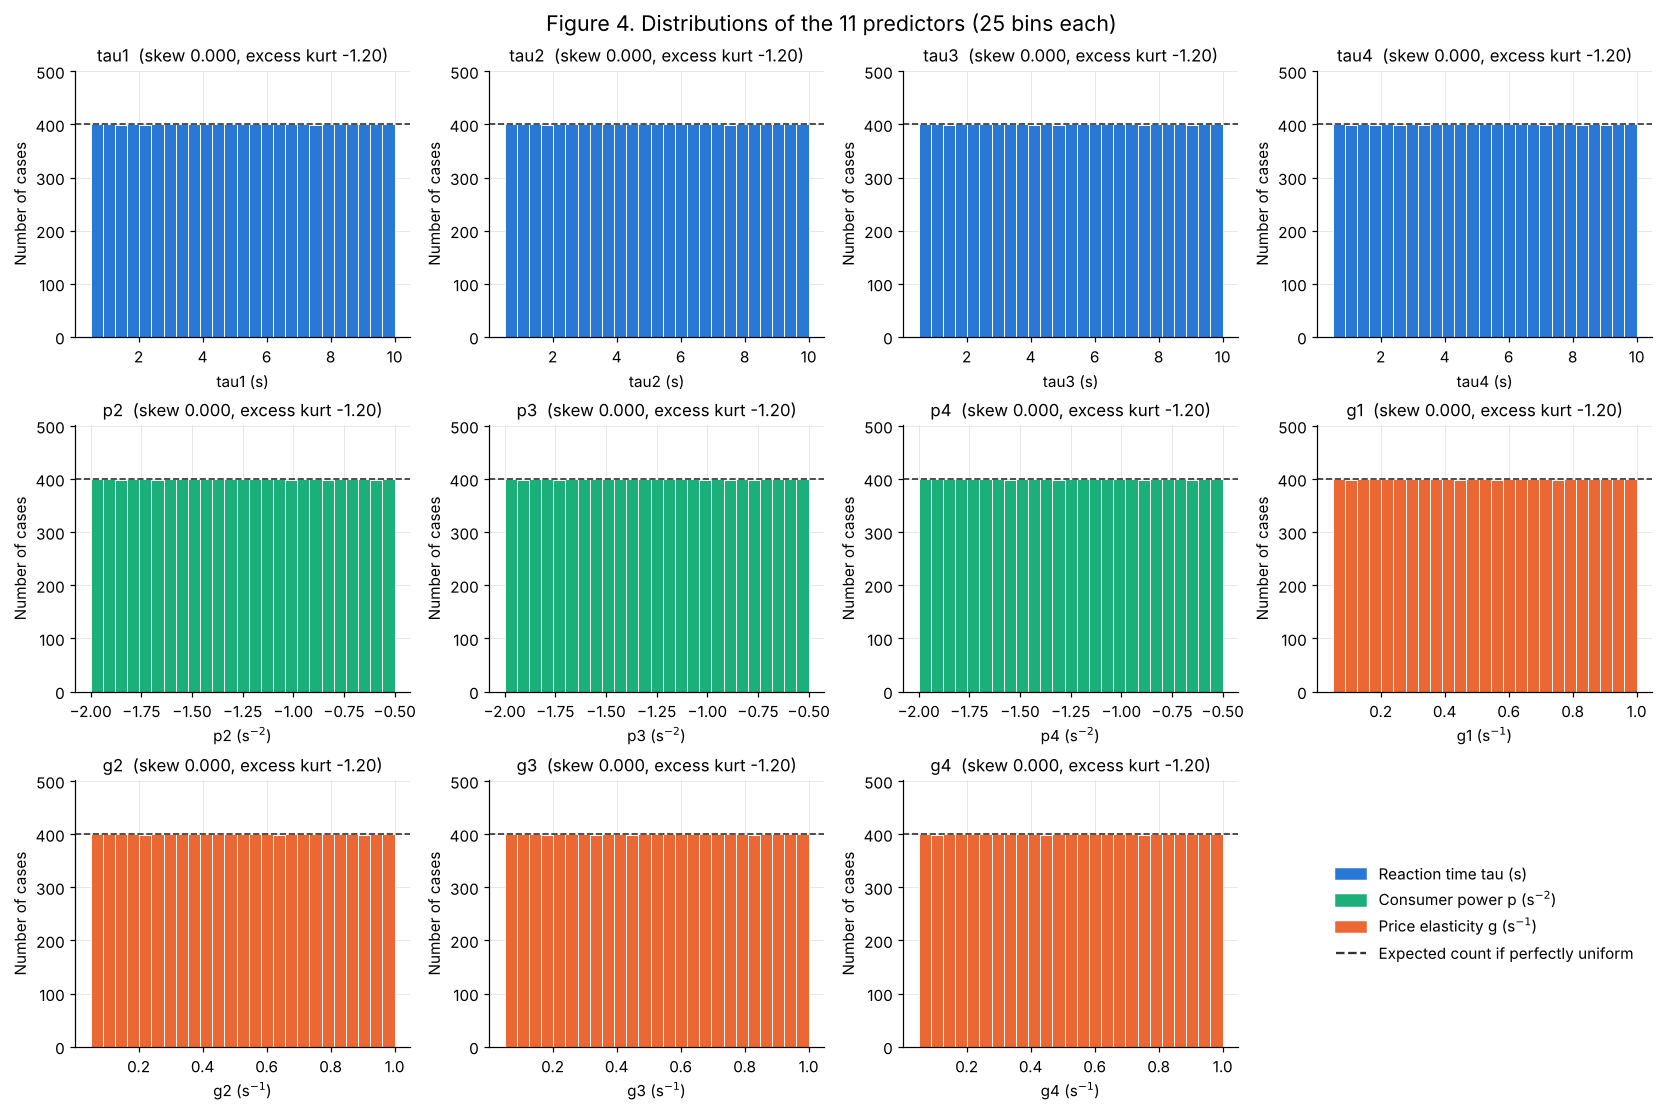

In [8]:
predictors = [*tau_cols, *consumer_p, *g_cols]
assert len(predictors) == 11 and not {'p1', 'stab', 'stabf'}.intersection(predictors)
print('Predictors:', ', '.join(predictors))

# Summary statistics table for all predictors
predictor_summary = df[predictors].describe().T
predictor_summary['skewness'] = df[predictors].skew()
predictor_summary['excess_kurtosis'] = df[predictors].kurtosis()
display(predictor_summary.round(4))
predictor_summary.to_csv(TABLE_DIR / 'predictor_summary.csv')

# Distribution-type check against a uniform distribution on each documented range
DOCUMENTED_RANGE = {**{c: (0.5, 10.0) for c in tau_cols}, **{c: (-2.0, -0.5) for c in consumer_p},
                    **{c: (0.05, 1.0) for c in g_cols}}
def ks_distance_uniform(values, low, high):
    # Kolmogorov-Smirnov D statistic versus U(low, high), computed with numpy only
    x = np.sort(np.asarray(values))
    n = len(x)
    cdf = (x - low) / (high - low)
    return float(max(np.max(np.arange(1, n + 1) / n - cdf), np.max(cdf - np.arange(0, n) / n)))

ks_critical = 1.36 / np.sqrt(len(df))
distribution_check = pd.DataFrame({
    'skewness': predictor_summary['skewness'],
    'excess_kurtosis': predictor_summary['excess_kurtosis'],
    'KS_D_vs_uniform': [ks_distance_uniform(df[c], *DOCUMENTED_RANGE[c]) for c in predictors],
})
distribution_check['uniform_reference'] = 'skew 0, kurt -1.2'
# Stratification check: does each of n equal-width strata of the range hold exactly one value?
distribution_check['one_value_per_stratum'] = [
    np.unique(np.minimum(((df[c] - DOCUMENTED_RANGE[c][0]) / (DOCUMENTED_RANGE[c][1] - DOCUMENTED_RANGE[c][0])
                          * len(df)).astype(int), len(df) - 1)).size == len(df) for c in predictors]
distribution_check['distribution_type'] = np.where(
    (distribution_check['skewness'].abs() < 0.05) & ((distribution_check['excess_kurtosis'] + 1.2).abs() < 0.05)
    & (distribution_check['KS_D_vs_uniform'] < ks_critical), 'Uniform', 'Not uniform')
print(f'KS 5% critical value for n={len(df)}: {ks_critical:.4f}')
display(distribution_check.style.format({'skewness': '{:.5f}', 'excess_kurtosis': '{:.4f}', 'KS_D_vs_uniform': '{:.6f}'}))
distribution_check.to_csv(TABLE_DIR / 'distribution_check.csv')

# Histograms of all 11 predictors with the ideal uniform density as a reference line
fig, axes = plt.subplots(3, 4, figsize=(15, 10), constrained_layout=True)
group_of = lambda c: 'tau' if c.startswith('tau') else ('g' if c.startswith('g') else 'p')
for ax, col in zip(axes.flat, predictors):
    counts, edges, _ = ax.hist(df[col], bins=25, color=GROUP_COLORS[group_of(col)], edgecolor='white', linewidth=0.6)
    ax.axhline(len(df) / 25, color='#333333', linestyle='--', linewidth=1.1)
    ax.set_title(f"{col}  (skew {round(df[col].skew(), 3) + 0.0:.3f}, excess kurt {df[col].kurtosis():.2f})")
    ax.set_xlabel(label_with_unit(col))
    ax.set_ylabel('Number of cases')
    ax.set_ylim(0, counts.max() * 1.25)
legend_ax = axes.flat[-1]
legend_ax.axis('off')
legend_ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS['tau']),
                          plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS['p']),
                          plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS['g']),
                          Line2D([0], [0], color='#333333', linestyle='--')],
                 labels=['Reaction time tau (s)', 'Consumer power p (s$^{-2}$)', 'Price elasticity g (s$^{-1}$)',
                         'Expected count if perfectly uniform'],
                 loc='center', frameon=False, fontsize=10)
fig.suptitle('Figure 4. Distributions of the 11 predictors (25 bins each)', fontsize=14)
fig.savefig(FIGURE_DIR / '04_predictor_distributions.png')
plt.show()

**Observations (Task 4)**

- **Distribution type: all 11 predictors are uniformly distributed** over their documented ranges. Skewness is ≈ 0 (symmetric), excess kurtosis is ≈ −1.20 (the exact theoretical value for a uniform distribution, i.e. flat with no tails), and every histogram bar sits on the "perfectly uniform" reference line in Figure 4. None of the predictors is normal or skewed.
- The inputs are in fact *more* uniform than random draws could be. Every 25-bin histogram has exactly 400 cases per bin, the KS distance is D ≈ 0.0001 (= 1/n, the smallest possible value, about 136 times below the 0.0136 critical value), and the stratification check shows that **each of the 10,000 equal-width strata of every range contains exactly one value**. This is the signature of **Latin hypercube sampling**, a space-filling design-of-experiments method, rather than random sampling. Engineering consequence: the histograms describe the *simulation design*, not how often real grids operate at these settings; e.g. a reaction time of 10 s is as common here as 1 s.
- **Scale differences:** `tau` spans 0.5–10 s (std ≈ 2.74), `p` spans 1.5 s⁻² (std ≈ 0.43) and `g` spans 0.95 s⁻¹ (std ≈ 0.27). The predictors differ in scale by up to ~10×, so scale-sensitive models (logistic regression, SVM, k-NN, neural networks) will need standardisation.
- There are no outliers, gaps or spikes in any predictor, so no transformation (log, Box-Cox) is required.

## 5. Multivariate analysis (Task 5)

1. **Correlation heatmap** of the 11 predictors and the binary target (Pearson; with a 0/1 target this equals the *point-biserial* correlation).
2. **Top 3 predictors** by absolute correlation with the target.
3. **Multicollinearity**: pairwise screen at |r| ≥ 0.80 and **variance inflation factors (VIF)**, plus a demonstration of why `p1` must be excluded.
4. **Pairplot** of the key features coloured by class.
5. Because pairwise linear correlation can miss non-linear effects, two further views: the **unstable rate across deciles** of each predictor, and an **interaction** view of reaction time × elasticity.

Top 3 features correlated with the target (stable = 0, unstable = 1):


,rank,feature,point_biserial_r
0,1,tau2,0.2463
1,2,tau4,0.2394
2,3,tau3,0.2375


All predictors ranked by |r| with the target:


,tau2,tau4,tau3,tau1,g3,g2,g4,g1,p4,p2,p3
r_with_target,0.2463,0.2394,0.2375,0.2349,0.2318,0.2173,0.2049,0.1977,-0.0228,0.0062,-0.0006


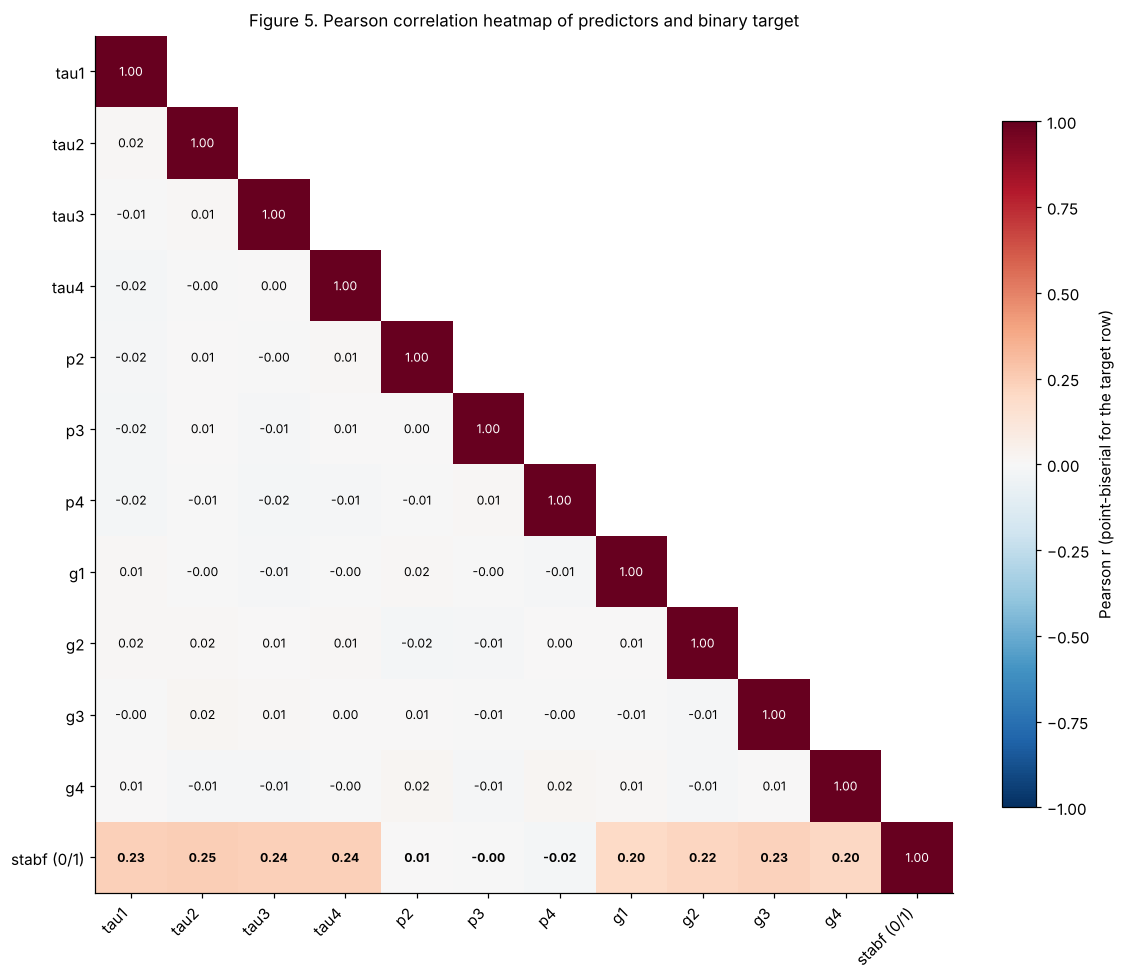

In [9]:
analysis_frame = df[predictors].copy()
analysis_frame['stabf_binary'] = y_binary.astype(int)
corr = analysis_frame.corr(method='pearson')

# Correlation of each predictor with the target, ranked by absolute value (sign kept)
target_corr = corr['stabf_binary'].drop('stabf_binary')
ranked = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
top3 = ranked.index[:3].tolist()
top3_table = pd.DataFrame({'rank': [1, 2, 3], 'feature': top3, 'point_biserial_r': ranked.iloc[:3].values.round(4)})
print('Top 3 features correlated with the target (stable = 0, unstable = 1):')
display(top3_table)
top3_table.to_csv(TABLE_DIR / 'top3_target_correlations.csv', index=False)
print('All predictors ranked by |r| with the target:')
display(ranked.round(4).rename('r_with_target').to_frame().T)

# Annotated heatmap (lower triangle only, diverging palette centred on 0)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(10.5, 8.8), constrained_layout=True)
image = ax.imshow(np.ma.masked_where(mask, corr), cmap='RdBu_r', vmin=-1, vmax=1)
labels = [c if c != 'stabf_binary' else 'stabf (0/1)' for c in corr.columns]
ax.set_xticks(range(len(corr)), labels, rotation=45, ha='right')
ax.set_yticks(range(len(corr)), labels)
ax.grid(False)
for i in range(len(corr)):
    for j in range(i + 1):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(v) > 0.6 else 'black', fontweight='bold' if (i == len(corr) - 1 and j < i) else 'normal')
ax.set_title('Figure 5. Pearson correlation heatmap of predictors and binary target')
fig.colorbar(image, ax=ax, shrink=0.8, label='Pearson r (point-biserial for the target row)')
fig.savefig(FIGURE_DIR / '05_correlation_heatmap.png')
plt.show()

In [10]:
# Multicollinearity (1): pairwise screen between predictors at |r| >= 0.80
predictor_corr = corr.loc[predictors, predictors]
off_diag = predictor_corr.where(~np.eye(len(predictors), dtype=bool))
print(f'Largest |r| between any two predictors: {off_diag.abs().max().max():.3f}')
high_pairs = [(a, b, predictor_corr.loc[a, b]) for i, a in enumerate(predictors) for b in predictors[i + 1:]
              if abs(predictor_corr.loc[a, b]) >= 0.80]
high_pairs_table = pd.DataFrame(high_pairs, columns=['feature_1', 'feature_2', 'pearson_r'])
print('Predictor pairs with |r| >= 0.80:', len(high_pairs_table))
high_pairs_table.to_csv(TABLE_DIR / 'high_correlation_pairs.csv', index=False)

# Multicollinearity (2): variance inflation factors, VIF_j = diagonal of the inverse correlation matrix
vif = pd.Series(np.diag(np.linalg.inv(predictor_corr.to_numpy())), index=predictors, name='VIF')
display(vif.round(3).to_frame().T)
vif.to_csv(TABLE_DIR / 'vif.csv')

# Multicollinearity (3): what happens if p1 were kept
power_cols = ['p1', 'p2', 'p3', 'p4']
print('Correlation of p1 with the consumer powers:')
display(df[power_cols].corr().loc[['p1'], ['p2', 'p3', 'p4']].round(3))
residual = (df.p1 + df.p2 + df.p3 + df.p4).abs().max()
print(f'max |p1 + p2 + p3 + p4| = {residual:.1e}  -> p1 is an exact linear combination (perfect multicollinearity)')
print('Rank of [p1, p2, p3, p4] design matrix:', np.linalg.matrix_rank(df[power_cols].to_numpy() - df[power_cols].mean().to_numpy()), 'of 4')

Largest |r| between any two predictors: 0.020
Predictor pairs with |r| >= 0.80: 0


,tau1,tau2,tau3,tau4,p2,p3,p4,g1,g2,g3,g4
VIF,1.002,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.002,1.001,1.002


Correlation of p1 with the consumer powers:


,p2,p3,p4
p1,-0.573,-0.585,-0.579


max |p1 + p2 + p3 + p4| = 5.8e-15  -> p1 is an exact linear combination (perfect multicollinearity)
Rank of [p1, p2, p3, p4] design matrix: 3 of 4


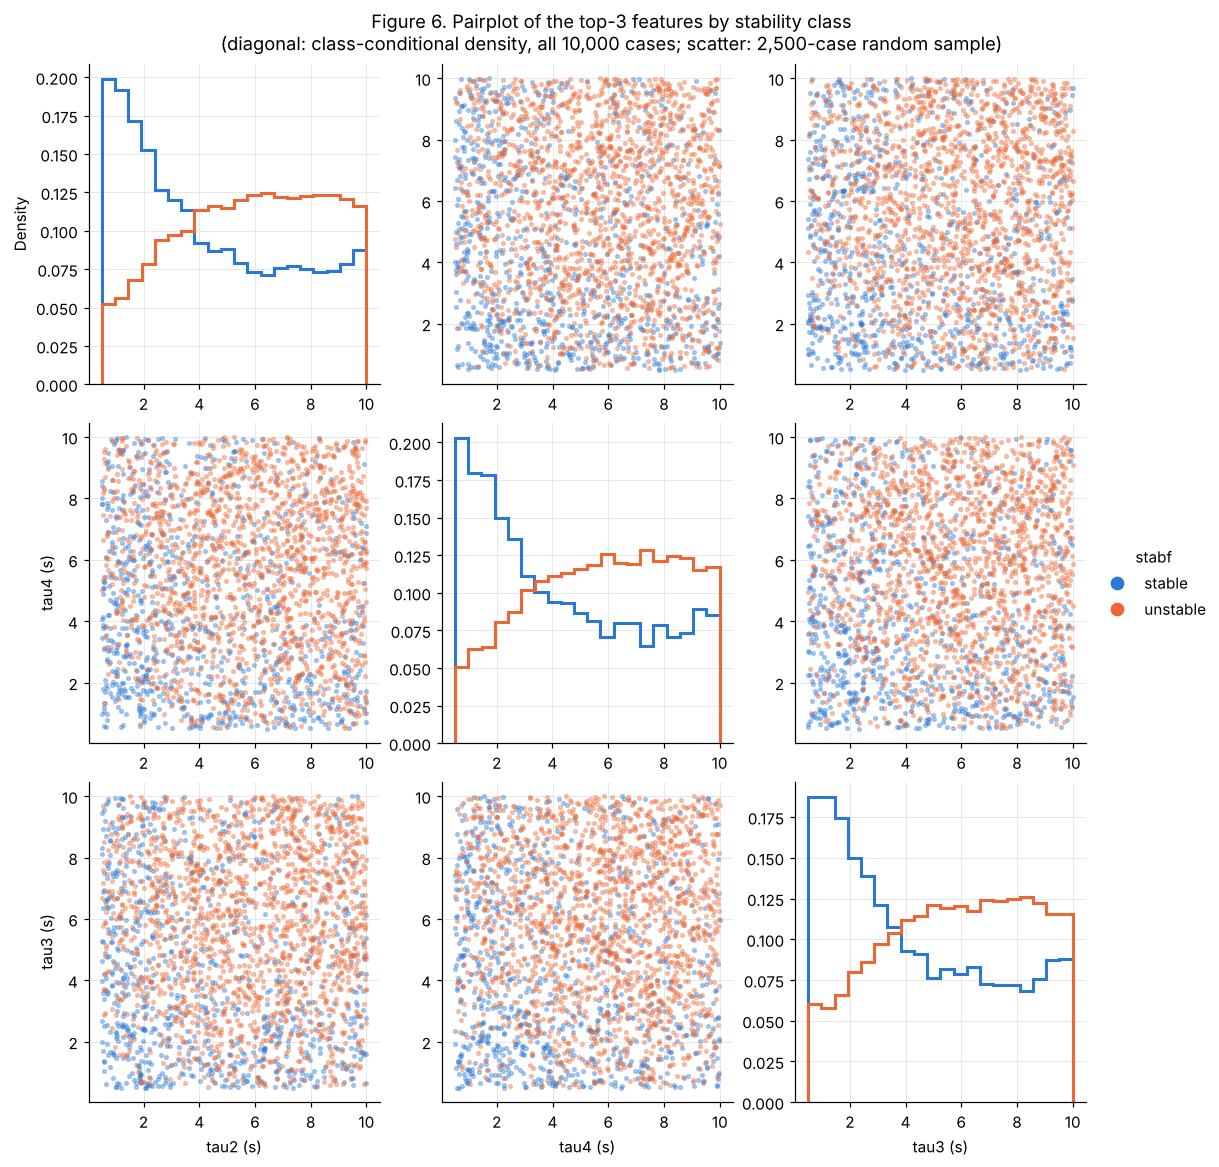

In [11]:
# Pairplot of the three key features (top 3 correlated with the target), coloured by class.
# A fixed 2,500-row sample keeps the scatter readable; all statistics above use all 10,000 rows.
plot_df = df[top3 + [target]].sample(n=2500, random_state=RANDOM_SEED)
fig, axes = plt.subplots(3, 3, figsize=(11, 10.5), constrained_layout=True)
for r, y_feat in enumerate(top3):
    for c, x_feat in enumerate(top3):
        ax = axes[r, c]
        if r == c:   # diagonal: class-conditional distribution
            for label in label_order:
                ax.hist(df.loc[df[target] == label, x_feat], bins=20, density=True, histtype='step',
                        linewidth=2, color=CLASS_COLORS[label])
            ax.set_ylabel('Density' if c == 0 else '')
        else:        # off-diagonal: scatter
            for label in label_order:
                part = plot_df[plot_df[target] == label]
                ax.scatter(part[x_feat], part[y_feat], s=6, alpha=0.35, color=CLASS_COLORS[label], rasterized=True)
            if c == 0:
                ax.set_ylabel(label_with_unit(y_feat))
        if r == 2:
            ax.set_xlabel(label_with_unit(x_feat))
handles = [Line2D([0], [0], marker='o', linestyle='', markersize=8, color=CLASS_COLORS[l], label=l) for l in label_order]
fig.legend(handles=handles, title='stabf', loc='outside right center', frameon=False)
fig.suptitle('Figure 6. Pairplot of the top-3 features by stability class\n'
             '(diagonal: class-conditional density, all 10,000 cases; scatter: 2,500-case random sample)', fontsize=12)
fig.savefig(FIGURE_DIR / '06_key_feature_pairplot.png')
plt.show()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10
tau1,32.5,44.0,56.7,68.2,70.6,74.3,76.4,73.7,72.1,69.5
tau2,32.8,44.3,57.6,64.7,69.9,73.8,74.8,73.9,74.7,71.5
tau3,35.6,44.2,55.3,65.4,71.2,72.7,73.2,75.1,75.3,70.0
tau4,34.2,43.6,57.5,66.4,69.2,73.9,72.4,75.5,75.1,70.2
p2,64.2,62.4,65.4,61.7,64.6,62.1,63.1,65.7,65.0,63.8
p3,64.3,62.6,61.7,63.5,66.1,66.0,64.1,63.4,64.6,61.7
p4,65.3,65.9,63.7,63.6,62.4,65.2,65.3,65.3,61.5,59.8
g1,48.2,52.4,56.0,60.1,60.6,65.4,68.9,72.1,76.3,78.0
g2,48.1,50.1,53.7,58.1,63.6,64.9,70.2,74.4,77.2,77.7
g3,48.2,48.8,52.8,58.7,64.3,64.6,68.6,72.7,77.1,82.2


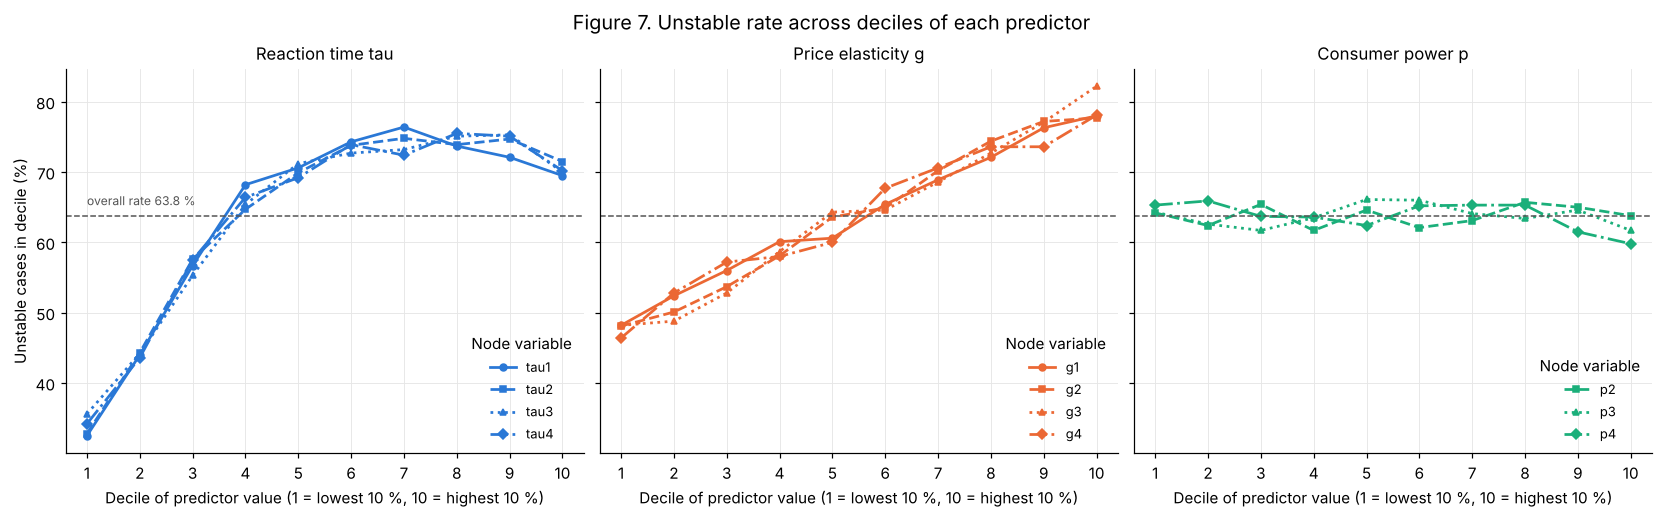

In [12]:
# Non-linear view: share of unstable cases within each decile of every predictor
decile_rates = {}
for col in predictors:
    decile = pd.qcut(df[col], 10, labels=False)
    decile_rates[col] = y_binary.groupby(decile).mean() * 100
decile_rates = pd.DataFrame(decile_rates)
decile_rates.index = [f'D{i + 1}' for i in range(10)]
display(decile_rates.round(1).T)
decile_rates.to_csv(TABLE_DIR / 'unstable_rate_by_decile.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True, constrained_layout=True)
groups = [('tau', tau_cols, 'Reaction time tau'), ('g', g_cols, 'Price elasticity g'), ('p', consumer_p, 'Consumer power p')]
x = np.arange(1, 11)
for ax, (key, cols, title) in zip(axes, groups):
    node_styles = [('-', 'o'), ('--', 's'), (':', '^'), ('-.', 'D')]
    for (ls, mk), col in zip(node_styles if key != 'p' else node_styles[1:], cols):
        ax.plot(x, decile_rates[col], linestyle=ls, marker=mk, markersize=4.5, linewidth=1.8,
                color=GROUP_COLORS[key], label=col)
    ax.legend(title='Node variable', frameon=False, fontsize=8.5, loc='lower right')
    ax.axhline(y_binary.mean() * 100, color='#555555', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xlabel('Decile of predictor value (1 = lowest 10 %, 10 = highest 10 %)')
    ax.set_xlim(0.6, 10.4)
axes[0].set_ylabel('Unstable cases in decile (%)')
axes[0].text(1, y_binary.mean() * 100 + 1.5, 'overall rate 63.8 %', fontsize=8, color='#555555')
fig.suptitle('Figure 7. Unstable rate across deciles of each predictor', fontsize=13)
fig.savefig(FIGURE_DIR / '07_unstable_rate_by_decile.png')
plt.show()

Point-biserial r of aggregate features vs best single predictor:


,tau_mean,g_mean,best single predictor (tau2)
r_with_target,0.478,0.427,0.246


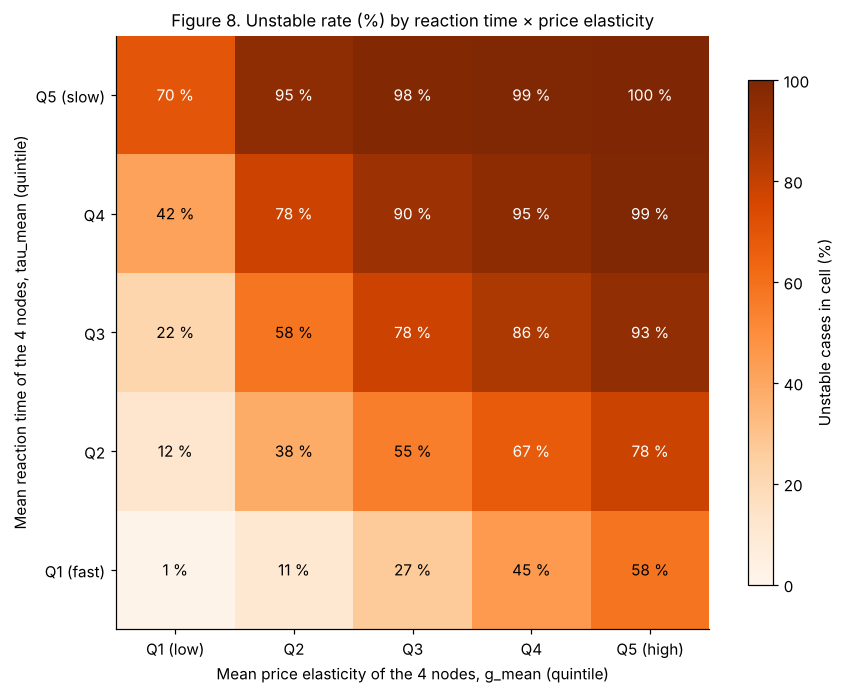

Fast + low elasticity corner: 1.2 % unstable | slow + high elasticity corner: 100.0 % unstable


In [13]:
# Interaction view: system-average reaction time x system-average elasticity
df_feat = pd.DataFrame({'tau_mean': df[tau_cols].mean(axis=1), 'g_mean': df[g_cols].mean(axis=1)})
aggregate_corr = pd.Series({'tau_mean': np.corrcoef(df_feat['tau_mean'], y_binary)[0, 1],
                            'g_mean': np.corrcoef(df_feat['g_mean'], y_binary)[0, 1],
                            'best single predictor (' + top3[0] + ')': ranked.iloc[0]}, name='r_with_target')
print('Point-biserial r of aggregate features vs best single predictor:')
display(aggregate_corr.round(3).to_frame().T)

tau_q = pd.qcut(df_feat['tau_mean'], 5, labels=['Q1 (fast)', 'Q2', 'Q3', 'Q4', 'Q5 (slow)'])
g_q = pd.qcut(df_feat['g_mean'], 5, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4', 'Q5 (high)'])
interaction = pd.crosstab(tau_q, g_q, values=y_binary * 100, aggfunc='mean')
interaction.to_csv(TABLE_DIR / 'interaction_tau_g.csv')

fig, ax = plt.subplots(figsize=(8.2, 6.2), constrained_layout=True)
im = ax.imshow(interaction.to_numpy(), cmap='Oranges', vmin=0, vmax=100, origin='lower')
ax.set_xticks(range(5), interaction.columns)
ax.set_yticks(range(5), interaction.index)
ax.grid(False)
for i in range(5):
    for j in range(5):
        v = interaction.iloc[i, j]
        ax.text(j, i, f'{v:.0f} %', ha='center', va='center', color='white' if v > 60 else 'black', fontsize=10)
ax.set_xlabel('Mean price elasticity of the 4 nodes, g_mean (quintile)')
ax.set_ylabel('Mean reaction time of the 4 nodes, tau_mean (quintile)')
ax.set_title('Figure 8. Unstable rate (%) by reaction time × price elasticity')
fig.colorbar(im, ax=ax, shrink=0.85, label='Unstable cases in cell (%)')
fig.savefig(FIGURE_DIR / '08_tau_g_interaction.png')
plt.show()
print(f'Fast + low elasticity corner: {interaction.iloc[0, 0]:.1f} % unstable | slow + high elasticity corner: {interaction.iloc[-1, -1]:.1f} % unstable')

**Observations (Task 5)**

*Top 3 features correlated with the target (point-biserial r, stable = 0 / unstable = 1; Figure 5, bottom row):*

1. **`tau2` — r = +0.246**
2. **`tau4` — r = +0.239**
3. **`tau3` — r = +0.238**

`tau1` (+0.235) is close behind, and all four elasticities follow (`g3` +0.232, `g2` +0.217, `g4` +0.205, `g1` +0.198). All eight correlations are **positive**: longer reaction times and stronger price elasticity are both associated with instability. The three consumer powers have r ≈ 0 (|r| ≤ 0.02).

*Multicollinearity:* none among the 11 predictors. The largest predictor–predictor |r| is only about 0.02, no pair reaches |r| ≥ 0.80, and every VIF is ≈ 1.00 (rule of thumb: VIF > 5–10 is a concern). This is again a consequence of the experimental design: each input was varied independently. However, `p1` would introduce **perfect multicollinearity**: it correlates at r ≈ −0.58 with each consumer power and p1 + p2 + p3 + p4 = 0 to machine precision (the power matrix has rank 3, not 4), which makes linear-model coefficients undefined. This confirms the decision to drop `p1`.

*Patterns and non-linear relationships:*

- **Pairplot (Figure 6):** the scatter panels show no structure *between* the tau variables (they are independent), but stable cases (blue) cluster in the low-tau region, especially where *two* reaction times are both small (bottom-left of each scatter). On the diagonals the stable density is high below ≈ 3 s and falls steeply, while the unstable density is flat-to-rising. The classes overlap heavily, so no single feature separates them.
- **Threshold/saturation effect (Figure 7):** for every `tau` the unstable rate rises steeply from about 33–36 % in the lowest decile (≈ 0.5–1.5 s) to about 70 % by the 5th decile (≈ 5 s), then **plateaus at roughly 70–76 %** (with a slight dip in the top decile). This is a non-linear, saturating relationship that a single linear coefficient underestimates. For `g` the rise is close to linear, from ≈ 46–48 % to ≈ 78–82 %. For `p` the lines stay flat around the overall rate (≈ 60–66 % vs 63.8 %): consumer power has essentially no marginal effect.
- **Interaction (Figure 8):** combining nodes is much more informative than any single node. The system-average reaction time and elasticity reach r ≈ 0.48 and 0.43, about twice the best single feature. In the 5 × 5 grid the unstable rate goes from **1 %** (fastest reaction, lowest elasticity) to **100 %** (slowest reaction, highest elasticity). The effect of elasticity depends on the reaction time (with fast reaction, moving from low to high elasticity raises instability from 1 % to 58 %; with slow reaction it is already 70 % at low elasticity): it is a strong **reaction time × elasticity interaction**, i.e. a non-linear decision boundary.

**Implication:** the linear correlations (≈ 0.25) understate how predictable stability is. Models that can represent interactions and thresholds (tree ensembles), or engineered features such as node-averaged `tau`/`g` and `tau × g` products, should perform far better than a plain linear model on the raw inputs.